# Entrega 2: CNN para Fashion-MNIST

Este notebook presenta la selección del dataset, su preparación, el diseño de una CNN propia, el entrenamiento, el análisis de curvas y la evaluación final.

## 1. Selección del conjunto de datos

Se utiliza Fashion-MNIST desde OpenML (`data_id=40996`). Fuente: https://www.openml.org/search?id=40996&sort=runs&type=data.

El conjunto contiene 70.000 imágenes, diez clases y dimensiones originales de 28x28 píxeles con un canal de escala de grises. Cada clase tiene 7.000 imágenes. La división estratificada deja 49.000 para entrenamiento, 10.500 para validación y 10.500 para prueba.

Las clases son T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag y Ankle boot. Se muestra la figura `outputs/figuras/ejemplos_clases.png` como evidencia visual. Fashion-MNIST es adecuado para CNN porque conserva bordes, formas y relaciones espaciales. No se utiliza aumento de datos.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import torch
from IPython.display import display, Image

E2_DIR = Path.cwd()
if E2_DIR.name != 'E_2':
    E2_DIR = next((p / 'E_2' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'E_2').is_dir()), E2_DIR)
sys.path.insert(0, str(E2_DIR / 'scripts'))
from descargar_fashion_mnist import preparar_dataset
from entrenar_cnn import ejecutar_entrenamiento
from visualizar_cnn import generar_figuras
from evaluar_cnn import evaluar

DATA_PATH = preparar_dataset(E2_DIR)
print('E_2:', E2_DIR)
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

Dataset local encontrado: C:\ITM\AprendizajeProfundo\Deep_learning_training\E_2\data\raw\fashion_mnist_openml.npz


Duplicados exactos de imagen: 0
E_2: C:\ITM\AprendizajeProfundo\Deep_learning_training\E_2
PyTorch: 2.14.0+cu130
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4070 Ti


## 2. Preparación de los datos

El Dataset propio entrega cada imagen como `[1, 28, 28]`. Se conserva un canal, se convierten los píxeles a `float32` y se dividen entre 255. Las particiones son 70 % para entrenamiento, 15 % para validación y 15 % para prueba. No se utilizan flips, rotaciones, recortes ni transformaciones aleatorias.

Train:

 49000
Validation: 10500
Test: 10500
Forma del lote: torch.Size([128, 1, 28, 28])
Tipo imagen: torch.float32 | Tipo etiqueta: torch.int64


,indice_original,label,clase
0,12420,7,Sneaker
1,17265,1,Trouser
2,49511,5,Sandal
3,49285,5,Sandal
4,27790,3,Dress


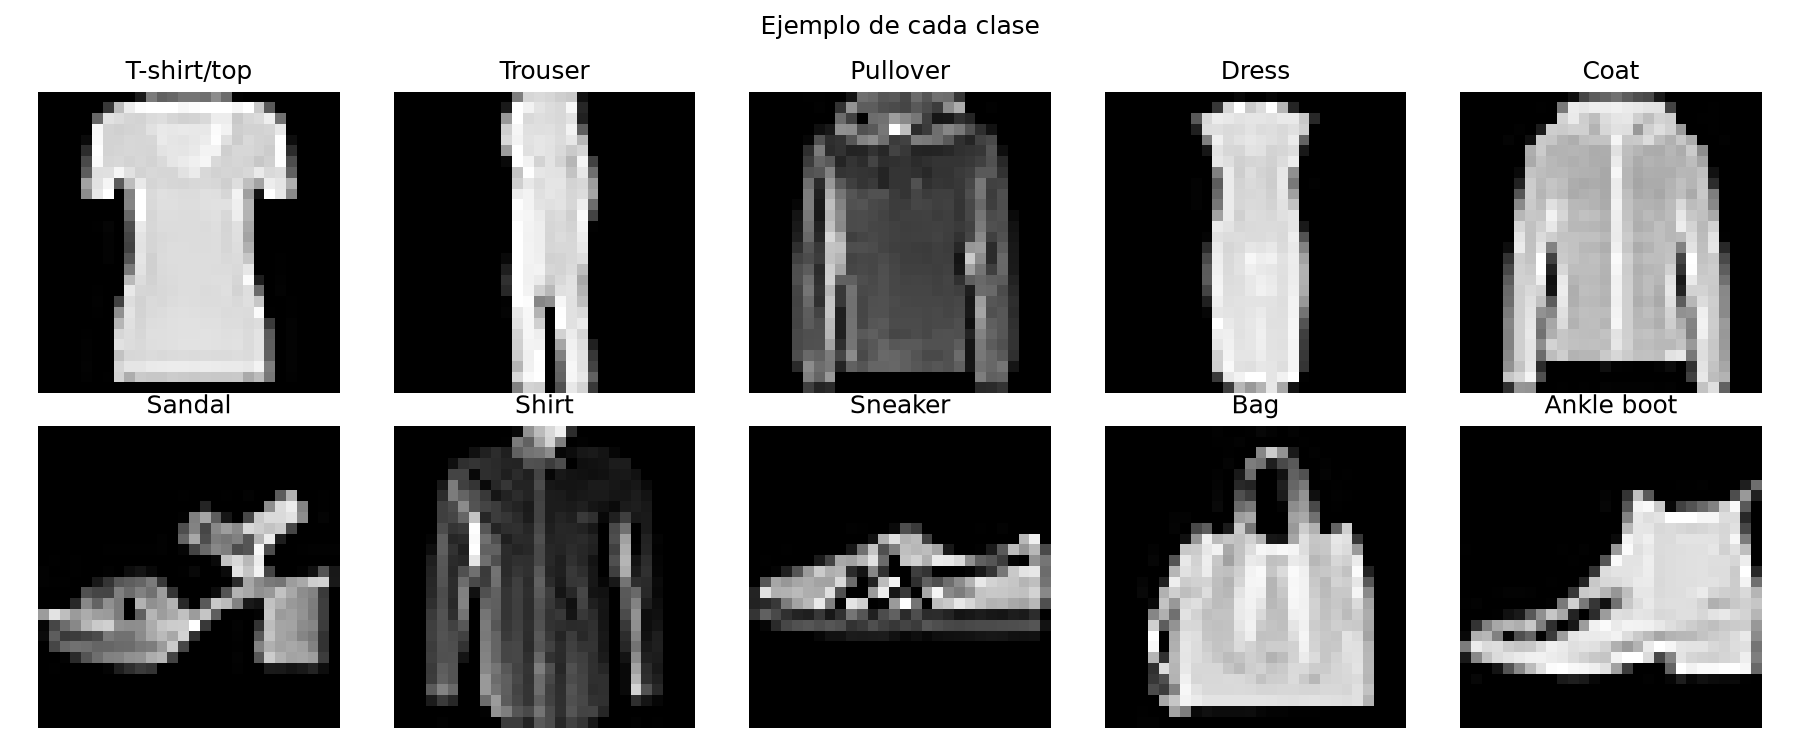

In [2]:
from datos_fashion import CargadorFashionMNIST
loader_info = CargadorFashionMNIST(DATA_PATH, batch_size=128)
batch_images, batch_labels = next(iter(loader_info.train_loader()))
print('Train:', len(loader_info.train_dataset))
print('Validation:', len(loader_info.val_dataset))
print('Test:', len(loader_info.test_dataset))
print('Forma del lote:', batch_images.shape)
print('Tipo imagen:', batch_images.dtype, '| Tipo etiqueta:', batch_labels.dtype)
display(pd.read_excel(E2_DIR / 'data' / 'processed' / 'datos_train.xlsx').head())
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'ejemplos_clases.png')))

## 3. Diseño de la arquitectura CNN

La CNN tiene tres capas convolucionales. Cada bloque usa convolución, ReLU y MaxPooling. Después se aplana el resultado y se utilizan capas completamente conectadas para clasificar las diez clases. La secuencia espacial es 28 → 14 → 7 → 3 y la salida de características es `[1, 64, 3, 3]`.

In [3]:
from modelo_cnn import CNNFashion
model_preview = CNNFashion(10)
print(model_preview)
print('Forma de características:', model_preview.feature_shapes())
print('Parámetros entrenables:', sum(p.numel() for p in model_preview.parameters() if p.requires_grad))

CNNFashion(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Forma de características: torch.Size([1, 64, 3, 3])
Parámetros entrenables: 98442


## 4. Entrenamiento

Se utiliza `CrossEntropyLoss`, Adam con learning rate 0.001, batch size 128 y un máximo de 20 épocas. En validación se usa `model.eval()` y `torch.no_grad()`. El checkpoint se selecciona por la menor pérdida de validación y no por el resultado de prueba.

In [4]:
resultado = ejecutar_entrenamiento(E2_DIR, epochs=20, patience=5)
historial = resultado['history']
display(historial)

CNNFashion(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Feature shape: torch.Size([1, 64, 3, 3])
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


Época 01/20 | train_loss=0.7960 | train_acc=70.3327% | val_loss=0.4853 | val_acc=82.1333%


Época 02/20 | train_loss=0.4756 | train_acc=82.5286% | val_loss=0.3799 | val_acc=86.2952%


Época 03/20 | train_loss=0.3996 | train_acc=85.2694% | val_loss=0.3322 | val_acc=87.7810%


Época 04/20 | train_loss=0.3535 | train_acc=87.0531% | val_loss=0.3036 | val_acc=89.0571%


...

Época 17/20 | train_loss=0.2016 | train_acc=92.4531% | val_loss=0.2257 | val_acc=92.1429%


Época 18/20 | train_loss=0.1925 | train_acc=92.7959% | val_loss=0.2213 | val_acc=92.0857%


Época 19/20 | train_loss=0.1892 | train_acc=92.8980% | val_loss=0.2267 | val_acc=91.8952%


Época 20/20 | train_loss=0.1799 | train_acc=93.2102% | val_loss=0.2279 | val_acc=92.0286%


,epoch,train_loss,val_loss,train_accuracy,val_accuracy
0,1,0.795999,0.485347,0.703327,0.821333
1,2,0.475640,0.379872,0.825286,0.862952
2,3,0.399625,0.332208,0.852694,0.877810
3,4,0.353512,0.303586,0.870531,0.890571
4,5,0.326514,0.293226,0.880306,0.891524
5,6,0.310129,0.277806,0.886327,0.897048
6,7,0.293921,0.263023,0.892408,0.904571
7,8,0.279184,0.264986,0.897878,0.902190
8,9,0.268563,0.269185,0.900633,0.900381
9,10,0.257428,0.251655,0.904878,0.913048


## 5. Análisis del entrenamiento

Las curvas permiten comparar entrenamiento y validación. Se revisa si la pérdida disminuye y si la accuracy aumenta sin que aparezca una separación excesiva entre ambas líneas.

Figuras guardadas en: C:\ITM\AprendizajeProfundo\Deep_learning_training\E_2\outputs\figuras


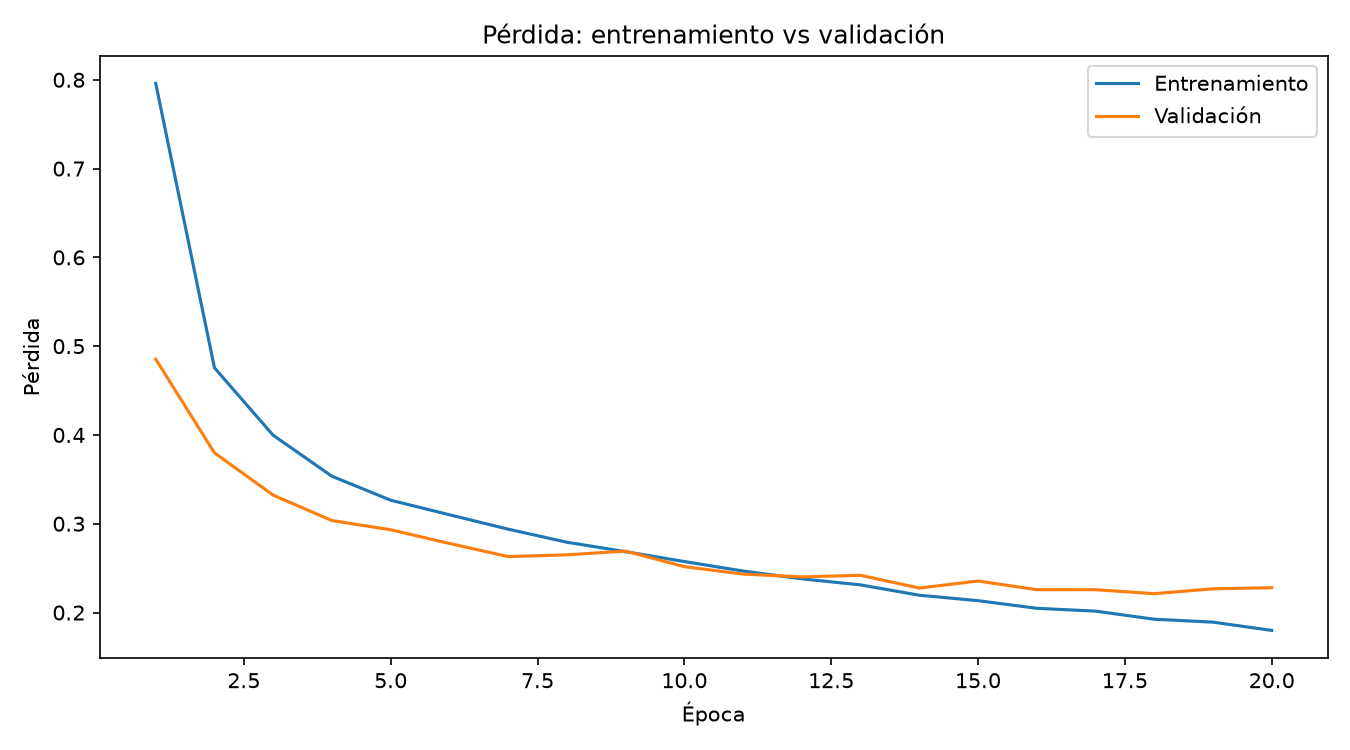

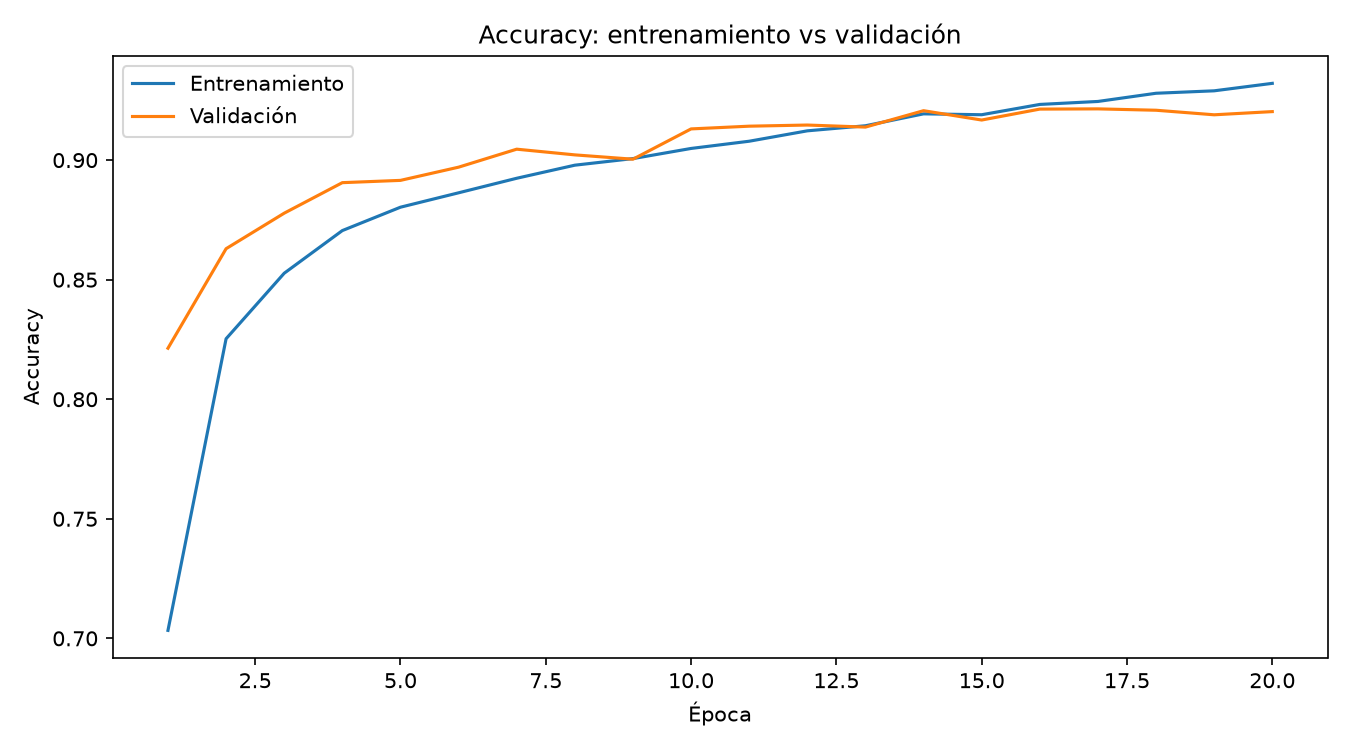

In [5]:
generar_figuras(E2_DIR, resultado)
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'curvas_perdida.png')))
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'curvas_accuracy.png')))

## 6. Evaluación sobre el conjunto de prueba

Después de cerrar las decisiones usando validación, se evalúa el checkpoint seleccionado sobre test. Se calculan accuracy, precision, recall, F1, especificidad, tasas de error, matrices de confusión y ROC-AUC one-vs-rest.

Test loss: 0.2317
Test accuracy: 91.55%
F1 macro: 91.48%
ROC-AUC macro: 0.9949


,test_loss,accuracy,f1_macro,f1_weighted,macro_auc,best_epoch,best_val_loss
0,0.231738,0.915524,0.914829,0.914829,0.994851,18,0.221258


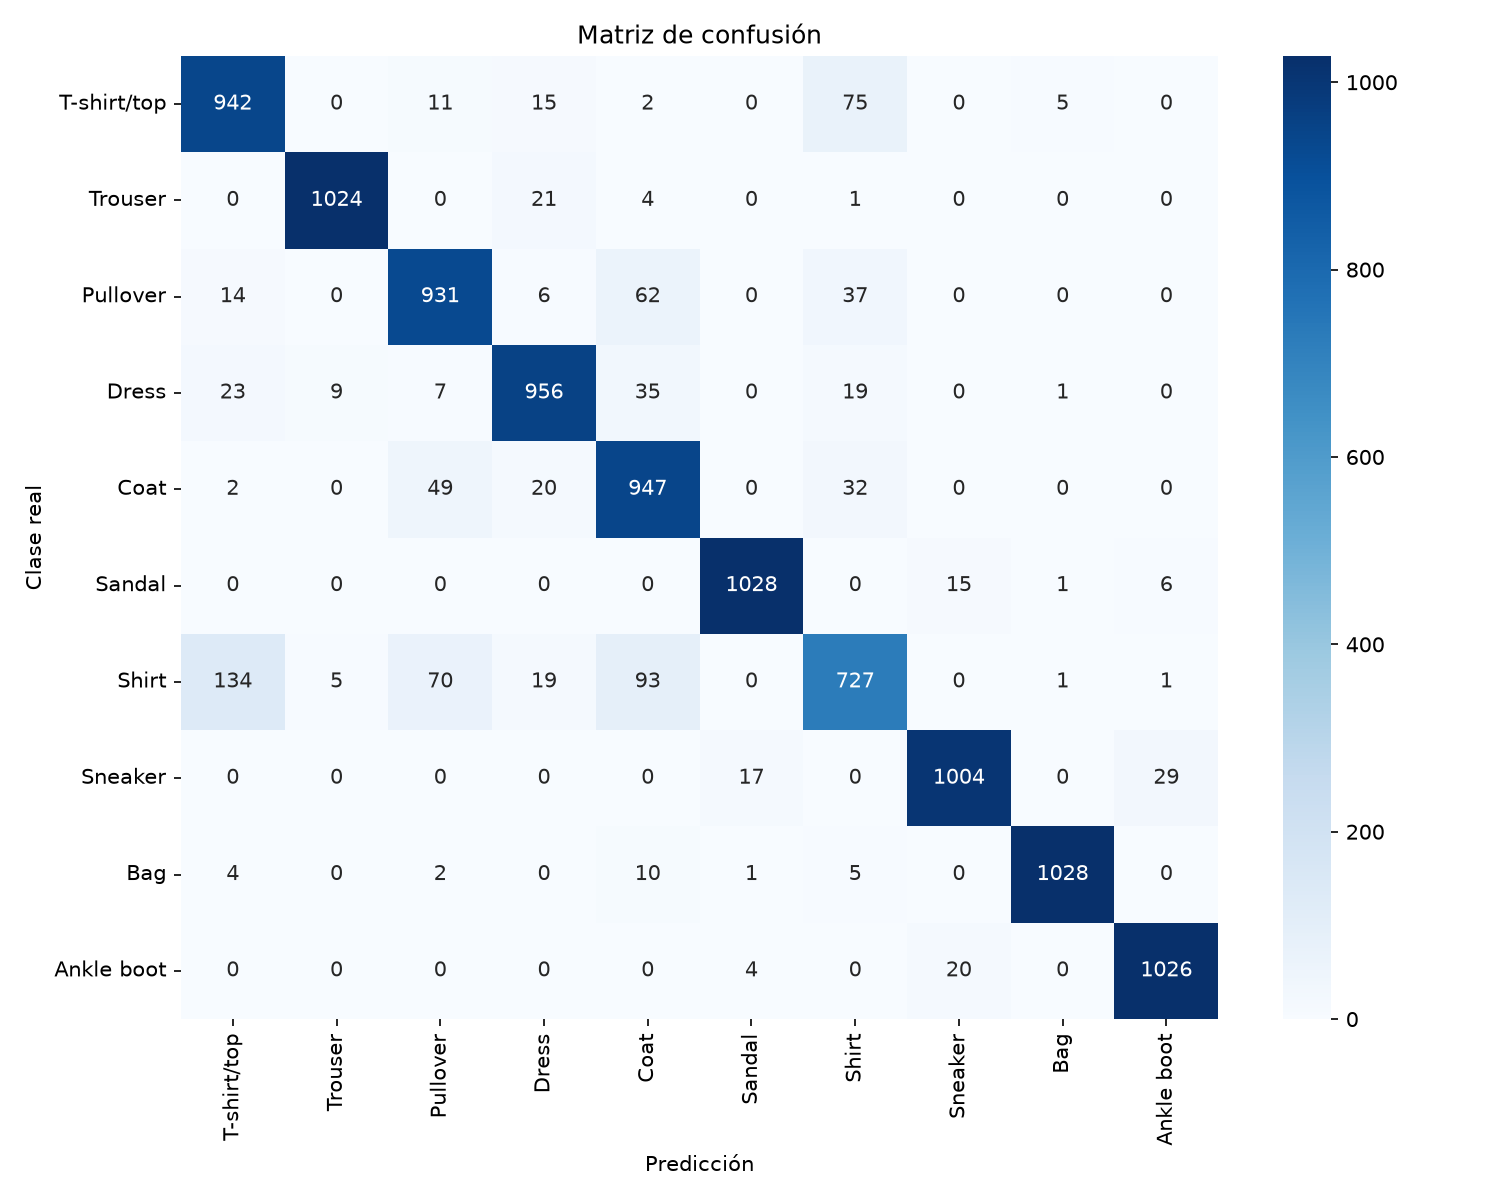

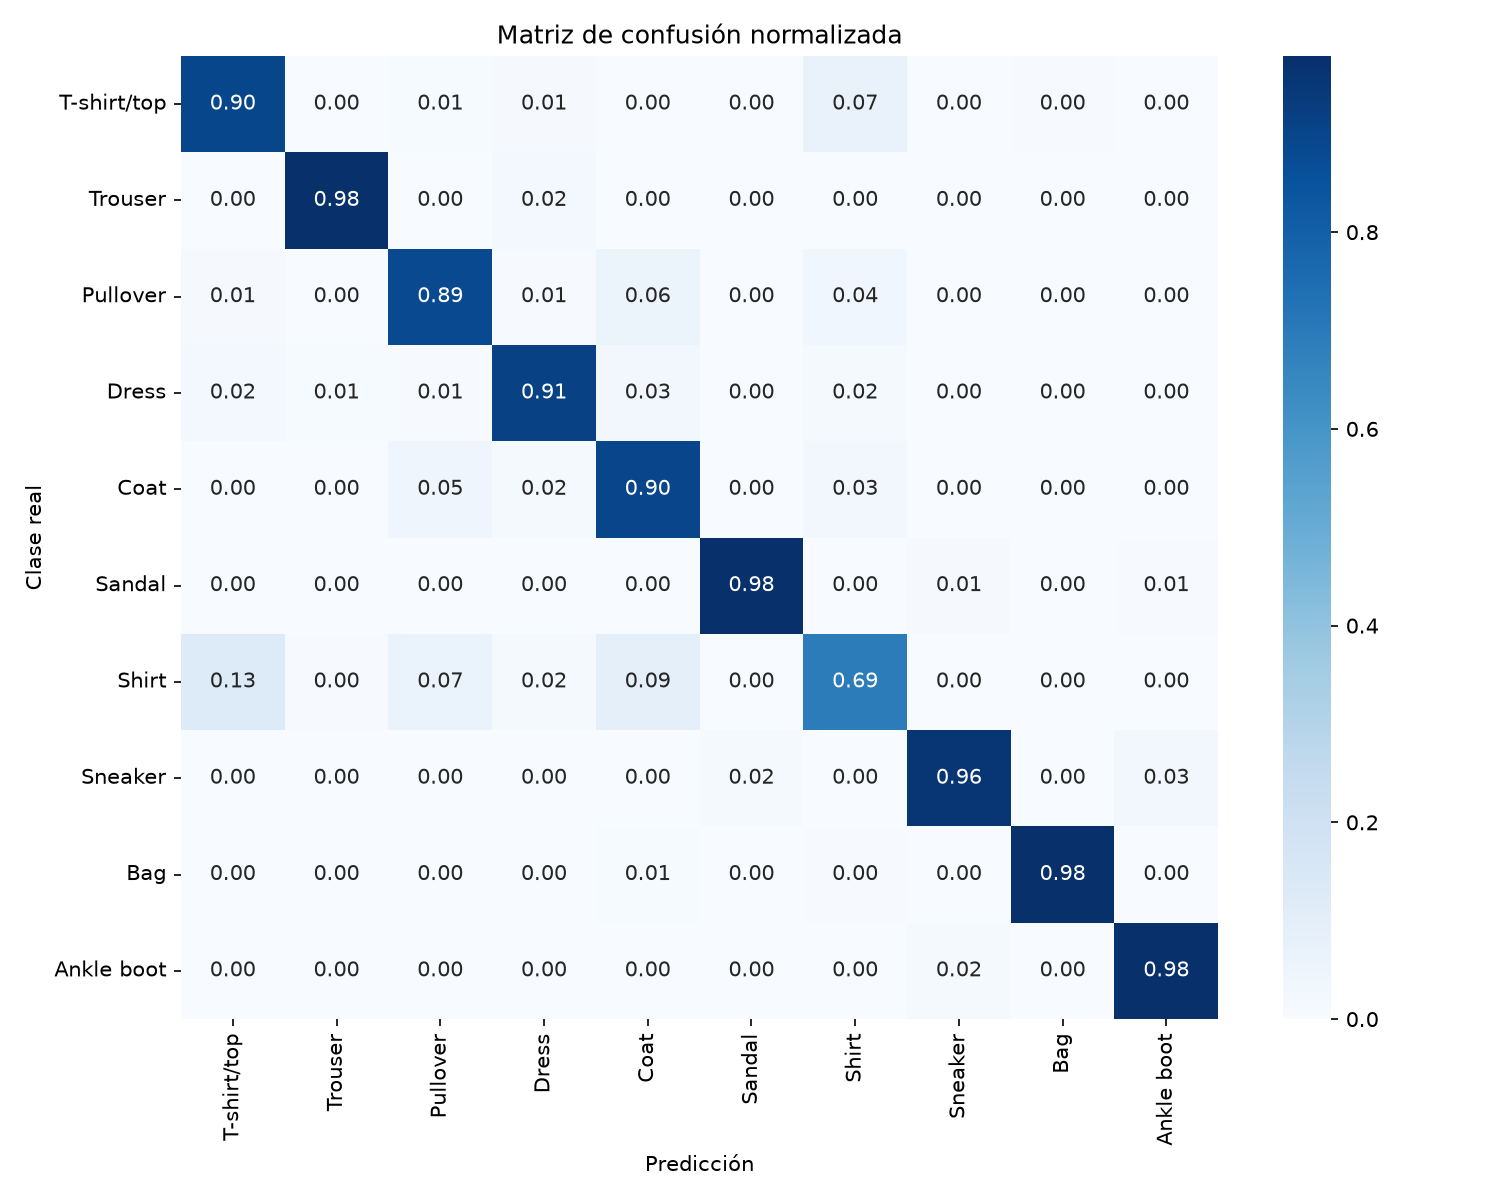

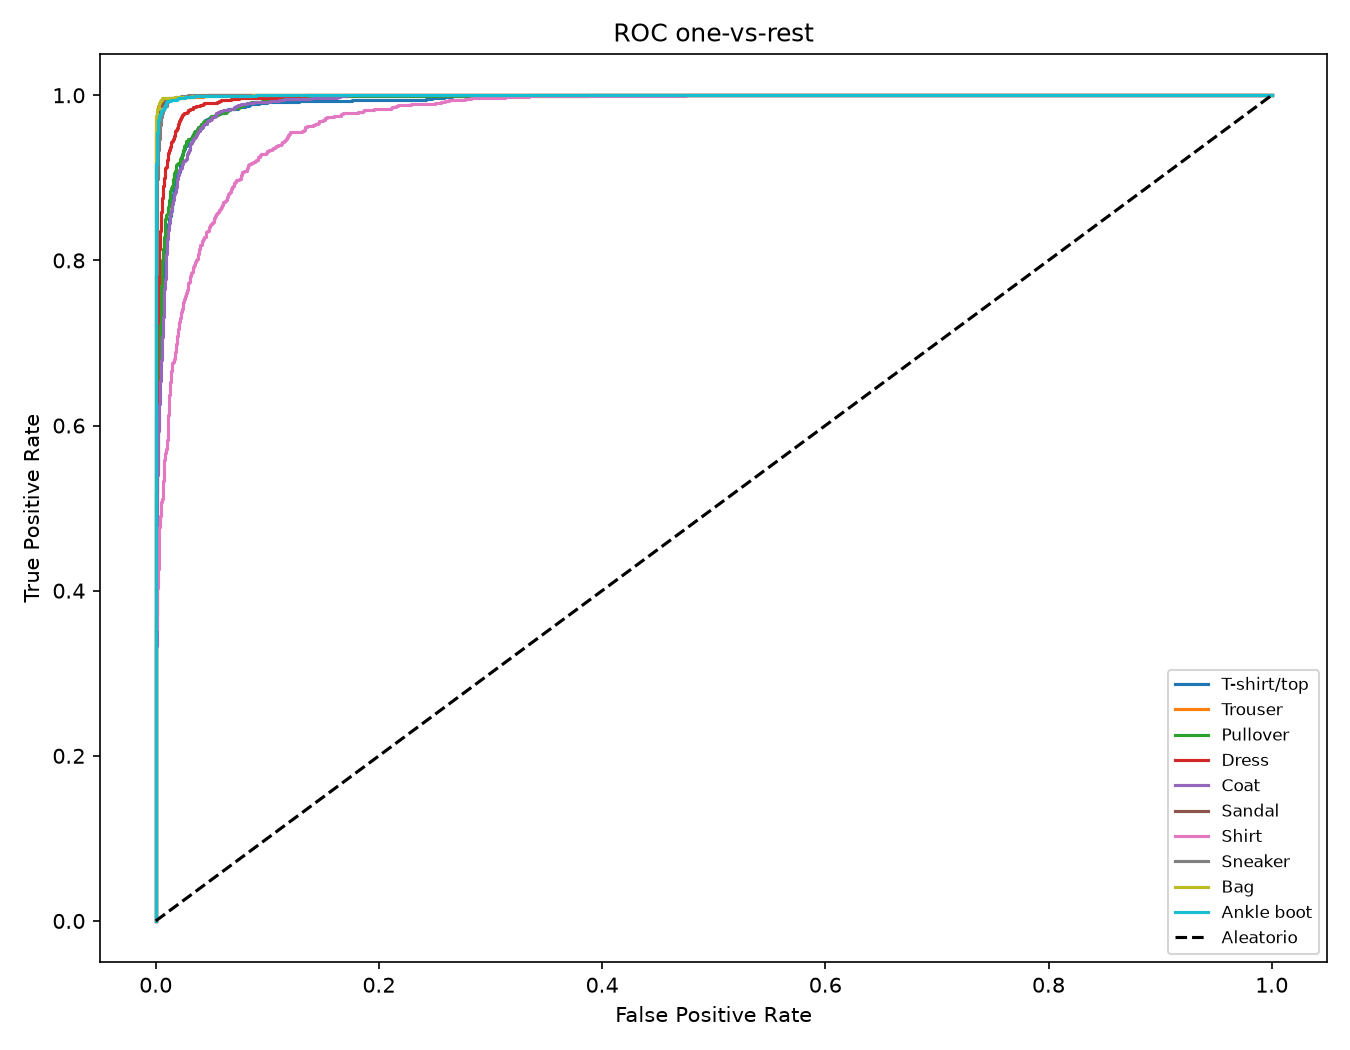

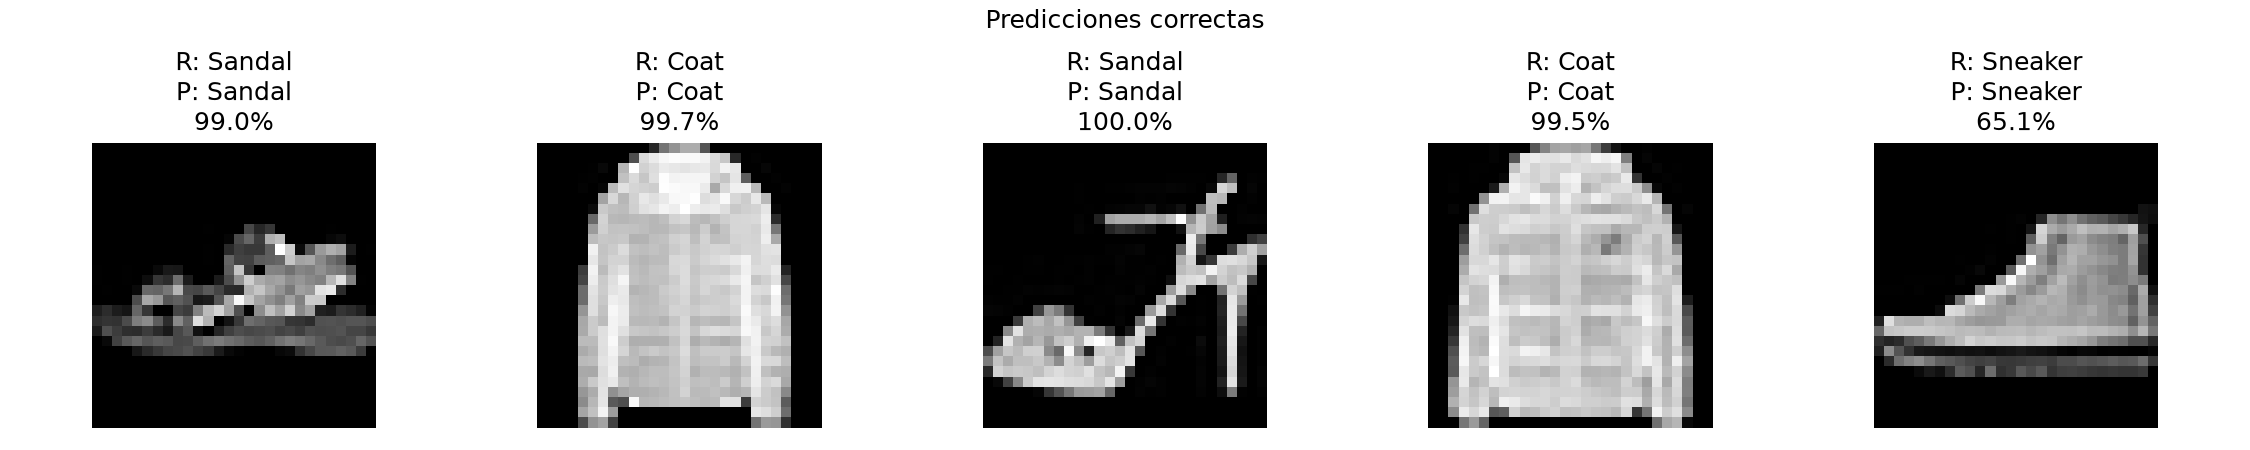

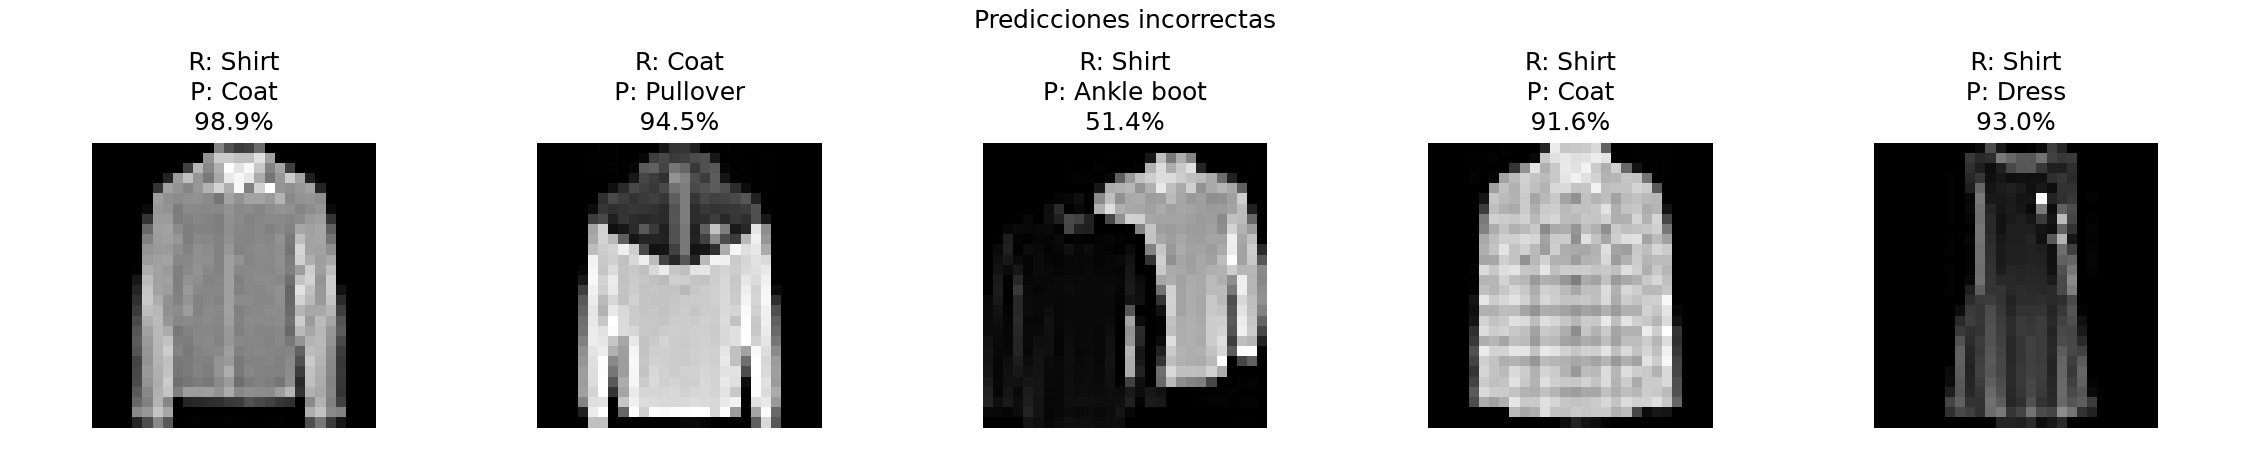

In [6]:
resumen = evaluar(resultado, E2_DIR)
display(pd.read_csv(E2_DIR / 'outputs' / 'metricas' / 'resumen_metricas.csv'))
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'matriz_confusion.png')))
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'matriz_confusion_normalizada.png')))
display(Image(filename=str(E2_DIR / 'outputs' / 'figuras' / 'roc_auc_por_clase.png')))
display(Image(filename=str(E2_DIR / 'outputs' / 'ejemplos' / 'correctas.png')))
display(Image(filename=str(E2_DIR / 'outputs' / 'ejemplos' / 'incorrectas.png')))

## 7. Preguntas de análisis

Las primeras capas convolucionales buscan patrones simples como bordes. Las capas posteriores combinan esos patrones y pueden representar formas más completas de las prendas. MaxPooling reduce la resolución espacial y disminuye el costo de las capas siguientes. Si se reemplazaran las convoluciones por capas densas, se perdería la conectividad local y el uso de pesos compartidos, aumentando el número de parámetros para procesar la imagen completa.

## Referencias

- OpenML Fashion-MNIST, data_id=40996.
- Zalando Research, Fashion-MNIST: https://github.com/zalandoresearch/fashion-mnist
- PyTorch documentation: https://pytorch.org/docs/stable/index.html
- Scikit-learn metrics: https://scikit-learn.org/stable/modules/model_evaluation.html